In [1]:
from src.post_processing import PathWrangler
import polars as pl
from pathlib import Path
from collections import defaultdict
from ergochemics.draw import draw_reaction, draw_molecule
from ergochemics.mapping import get_reaction_center
from rdkit import Chem
from IPython.display import display, SVG

In [ ]:
study = "/home/stef/quest_data/bottle/data/processed/short_test"
known = "/home/stef/bottle/artifacts/known"
# out_dir = "/home/stef/bottle/artifacts/coa_mutase_paths"

Direct look at parquet files

In [5]:
paths = pl.read_parquet(
    Path(study) / "paths.parquet"
)
paths.head()

path_id,rxn_id,main_pdt_id,rxn_type,generation
str,str,str,enum,i32
"""3c8971d19a1867e74768c9d6414454…","""a5d3aa5d707970ebd6fcf2fe358248…","""5dda37273fbd4aeb5ccf18108bdb9e…","""predicted""",1
"""eb12cc4c03b0afeef652b37bfb0ed8…","""a5d3aa5d707970ebd6fcf2fe358248…","""5dda37273fbd4aeb5ccf18108bdb9e…","""predicted""",1
"""3c8971d19a1867e74768c9d6414454…","""a5e65fd8889b5a0a22fe1653945c75…","""38a7ba45da81d5585c614c7be7aa96…","""predicted""",0
"""76b0f3e9f99adbe64c8e1bfb78887a…","""a5d3aa5d707970ebd6fcf2fe358248…","""5dda37273fbd4aeb5ccf18108bdb9e…","""predicted""",1
"""52052bf5277c88cd0acc3900dc5e70…","""a5d3aa5d707970ebd6fcf2fe358248…","""5dda37273fbd4aeb5ccf18108bdb9e…","""predicted""",1


In [12]:
paths.filter(pl.col("path_id") == '1298a5938599d2de790c2c03b74d872772f17046').row(0)

('1298a5938599d2de790c2c03b74d872772f17046',
 '5de340e14af087d10fb65147ff033f4e7a065e03',
 '5dda37273fbd4aeb5ccf18108bdb9ee979eb882b',
 'predicted',
 0)

In [4]:
path_stats = pl.read_parquet(
    Path(study) / "path_stats.parquet"
)
path_stats.head()

id,starters,targets,dg_opt,dg_err,starter_ids,target_ids,mdf,mean_max_rxn_sim,mean_mean_rxn_sim,min_max_rxn_sim,min_mean_rxn_sim,feasibility_frac
str,list[str],list[str],list[f32],list[f32],list[str],list[str],f32,f32,f32,f32,f32,f32
"""3c8971d19a1867e74768c9d6414454…","[""2-oxoglutarate""]","[""hopa""]",null,null,"[""6cf6db1d70f43061de31deeb417214c6fd7ad005""]","[""5dda37273fbd4aeb5ccf18108bdb9ee979eb882b""]",null,0.454685,0.399956,0.0,0.0,1.0
"""76b0f3e9f99adbe64c8e1bfb78887a…","[""2-oxoglutarate""]","[""hopa""]",null,null,"[""6cf6db1d70f43061de31deeb417214c6fd7ad005""]","[""5dda37273fbd4aeb5ccf18108bdb9ee979eb882b""]",null,0.837791,0.615684,0.766212,0.431456,1.0
"""eb12cc4c03b0afeef652b37bfb0ed8…","[""2-oxoglutarate""]","[""hopa""]",null,null,"[""6cf6db1d70f43061de31deeb417214c6fd7ad005""]","[""5dda37273fbd4aeb5ccf18108bdb9ee979eb882b""]",null,0.904546,0.687206,0.899721,0.5745,0.5
"""52052bf5277c88cd0acc3900dc5e70…","[""2-oxoglutarate""]","[""hopa""]",null,null,"[""6cf6db1d70f43061de31deeb417214c6fd7ad005""]","[""5dda37273fbd4aeb5ccf18108bdb9ee979eb882b""]",null,0.900055,0.671568,0.890741,0.543225,1.0
"""1298a5938599d2de790c2c03b74d87…",[],[null],null,null,[],"[""5dda37273fbd4aeb5ccf18108bdb9ee979eb882b""]",null,0.444142,0.312057,0.0,0.0,1.0


In [8]:
path_stats.row(4)

('1298a5938599d2de790c2c03b74d872772f17046',
 [],
 [None],
 None,
 None,
 [],
 ['5dda37273fbd4aeb5ccf18108bdb9ee979eb882b'],
 None,
 0.444141685962677,
 0.3120568096637726,
 0.0,
 0.0,
 1.0)

In [22]:
print(paths.shape)
print(paths.unique().shape)
print(path_stats.shape)
print(path_stats.unique().shape)

(51, 5)
(51, 5)
(26, 13)
(26, 13)


In [13]:
pred_rxns = pl.read_parquet(
    Path(study) / "predicted_reactions.parquet"
)
print(pred_rxns.shape)
pred_rxns.head()

(16, 9)


id,smarts,am_smarts,dxgb_label,rxn_sims,analogue_ids,rules,templates,rule_sets
str,str,str,i32,list[f32],list[str],list[str],list[str],list[str]
"""5f0f5291d8cc0b12ce4b74d4230e85…","""O=C(O)CCC(=O)C(=O)O.Nc1ncnc2c1…","""[O:1]=[C:2]([OH:3])[CH2:4][CH2…",1,"[0.890741, 0.890741, … 0.12188]","[""1291a1ba2a4ce39c1624cf3134d8742c2d92d586"", ""1d0e82dc4f2e0b95565c0fd2c0148fb817ab19f4"", … ""973959253d721c528f93df2b99af7c32c0dc10ef""]","[""330_5""]","[""[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])-[O&D1&v2&H1&+0&!R:3].[P&D4&v5&H0&+0&!R:4](=[O&D1&v2&H0&+0&!R:5])(-[O&D1&v2&H1&+0&!R:6])-[O&D2&v2&H0&+0&!R:7]-[P&D4&v5&H0&+0&!R:8](=[O&D1&v2&H0&+0&!R:9])(-[O&D1&v2&H1&+0&!R:10])-[O&D2&v2&H0&+0&!R:11]-[P&D4&v5&H0&+0&!R:12](=[O&D1&v2&H0&+0&!R:13])(-[O&D1&v2&H1&+0&!R:14])-[O&D1&v2&H1&+0&!R:15].[S&D1&v2&H1&+0&!R:16]>>[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])-[S&D2&v2&H0&+0&!R:16].[O&D1&v2&H0&+0&!R:9]=[P&D4&v5&H0&+0&!R:8](-[O&D1&v2&H1&+0&!R:7])(-[O&D1&v2&H1&+0&!R:10])-[O&D2&v2&H0&+0&!R:11]-[P&D4&v5&H0&+0&!R:12](=[O&D1&v2&H0&+0&!R:13])(-[O&D1&v2&H1&+0&!R:14])-[O&D1&v2&H1&+0&!R:15].[P&D4&v5&H0&+0&!R:4](=[O&D1&v2&H0&+0&!R:5])(-[O&D1&v2&H1&+0&!R:3])-[O&D1&v2&H1&+0&!R:6]""]","[""mechinferred_dt_13_rules_w_coreactants""]"
"""ffddd8026f4f6edae69756c34f23d7…","""O=C(O)CCC(=O)C(=O)O.Nc1ncnc2c1…","""[O:1]=[C:2]([OH:3])[CH2:4][CH2…",1,"[0.766212, 0.537178, … 0.101719]","[""7b6c223f1833236bdd8fec9b46592dcaf33265c2"", ""e084907adeeaa10c0e7f81514cb4954ebb1746e4"", … ""2f21085098ffeaf932f063c6bac3e81e09870b72""]","[""900_5""]","[""[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])-[O&D1&v2&H1&+0&!R:3].[P&D4&v5&H0&+0&!R:4](-[O&D1&v2&H1&+0&!R:5])-[O&D2&v2&H0&+0&!R:6]-[P&D4&v5&H0&+0&!R:7](=[O&D1&v2&H0&+0&!R:8])(-[O&D1&v2&H1&+0&!R:9])-[O&D2&v2&H0&+0&!R:10]-[P&D4&v5&H0&+0&!R:11](=[O&D1&v2&H0&+0&!R:12])(-[O&D1&v2&H1&+0&!R:13])-[O&D1&v2&H1&+0&!R:14].[S&D1&v2&H1&+0&!R:15]>>[O&D1&v2&H0&+0&!R:12]=[P&D4&v5&H0&+0&!R:11](-[O&D1&v2&H1&+0&!R:10])(-[O&D1&v2&H1&+0&!R:13])-[O&D1&v2&H1&+0&!R:14].[P&D4&v5&H0&+0&!R:4](-[O&D1&v2&H1&+0&!R:5])-[O&D2&v2&H0&+0&!R:6]-[P&D4&v5&H0&+0&!R:7](=[O&D1&v2&H0&+0&!R:8])(-[O&D1&v2&H1&+0&!R:3])-[O&D1&v2&H1&+0&!R:9].[S&D2&v2&H0&+0&!R:15]-[C&D3&v4&H0&+0&!R&z2:1]=[O&D1&v2&H0&+0&!R:2]""]","[""mechinferred_dt_13_rules_w_coreactants""]"
"""a5e65fd8889b5a0a22fe1653945c75…","""O=C(O)CCC(=O)C(=O)O.CC(=O)SCCN…","""[O:1]=[C:2]([OH:3])[CH2:4][CH2…",1,[],[],"[""1878_0"", ""55_0""]","[""[C&D1&v4&H3&+0&!R&z0:1]~[*:2]~[O&D1&v2&H0&+0&!R:3].[C&D3&v4&H0&+0&!R&z2:4](=[O&D1&v2&H0&+0&!R:5])-[C&D2&v4&H2&+0&!R&z0:6]-[C&D2&v4&H2&+0&!R&z0:7]>>[C&D1&v4&H3&+0&!R&z0:6]-[C&D3&v4&H0&+0&!R&z2:4]=[O&D1&v2&H0&+0&!R:5].[C&D2&v4&H2&+0&!R&z0:7]-[C&D2&v4&H2&+0&!R&z0:1]~[*:2]~[O&D1&v2&H0&+0&!R:3]"", ""[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])-[O&D1&v2&H1&+0&!R:3].[S&D2&v2&H0&+0&!R:4]-[C&D3&v4&H0&+0&!R&z2:5]=[O&D1&v2&H0&+0&!R:6]>>[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])-[S&D2&v2&H0&+0&!R:4].[O&D1&v2&H0&+0&!R:6]=[C&D3&v4&H0&+0&!R&z2:5]-[O&D1&v2&H1&+0&!R:3]""]","[""mechinferred_dt_13_rules_w_coreactants"", ""mechinferred_dt_13_rules_w_coreactants""]"
"""f39c8cbe03e24a5466d6f112c736e3…","""O=C(O)CCC(=O)C(=O)O.CC(C)(COP(…","""[O:1]=[C:2]([OH:3])[CH2:4][CH2…",0,"[0.899721, 0.899721, … 0.026379]","[""7f95dfa470852a4058288bb42b7dd0c9979d7758"", ""efb8e86eac891125f000d456179778d183b7b768"", … ""7d5b425a4d2eaf58fb412750783f5182ae17d0aa""]","[""886_2""]","[""[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])-[O&D1&v2&H1&+0&!R:3].[S&D1&v2&H1&+0&!R:4]>>[O&D0&v2&H2&+0&!R:3].[S&D2&v2&H0&+0&!R:4]-[C&D3&v4&H0&+0&!R&z2:1]=[O&D1&v2&H0&+0&!R:2]""]","[""mechinferred_dt_13_rules_w_coreactants""]"
"""a5d3aa5d707970ebd6fcf2fe358248…","""NC(=O)C1=CN(C2OC(COP(=O)(O)OP(…","""[NH2:106][C:107](=[O:108])[C:1…",1,"[0.90937, 0.90937, … 0.59492]","[""31baa990ad755676c60d510ab94e91c1a1bf67f3"", ""17005abea2aff963bfc40507eafa280833971ee4"", … ""562701df6cb01c76f36ea80ce0fa7244b8e38a23""]","[""898_3_reversed""]","[""[C&D3&v4&H0&+0&R&z0:13]1=[C&D2&v4&H1&+0&R&z1:21]-[N&D3&v3&H0&+0&R:17](-[C&D3&v4&H1&+0&R&z2:18]-[C&D

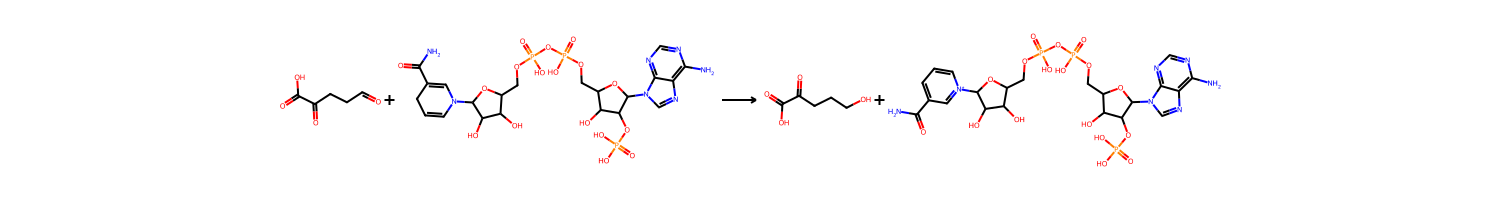

In [14]:
sma1 = pred_rxns.filter(
    pl.col("id").str.starts_with("5de340e14af087d10fb65147ff033f4e7a065e03")
)["smarts"][0]
display(SVG(draw_reaction(sma1)))

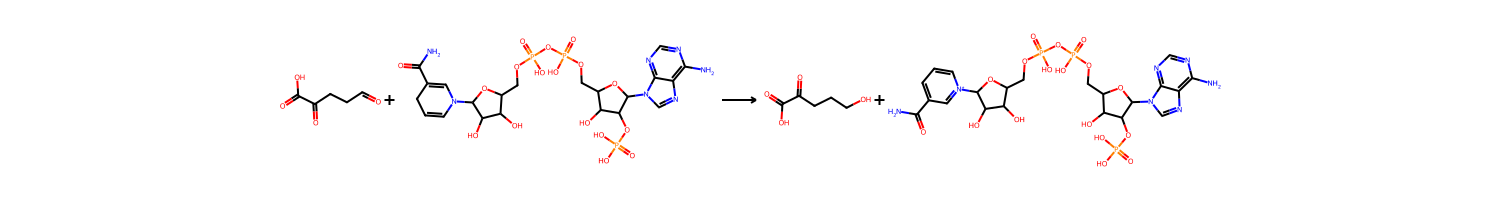

In [ ]:
sma2 = pred_rxns.filter(
    pl.col("id") == 'ad54e57aff5d4d78155a18e3aa3865239999a9bc'
)["smarts"][0]
display(SVG(draw_reaction(sma1)))

In [ ]:
display(SVG(draw_molecule()))

In [16]:
def get_rc_patts(am_rxn: str) -> tuple[str, str]:
    ''' Get reaction center pattern SMILES (left and right) from an atom-mapped reaction.'''
    sort_side = lambda side: ".".join(sorted(side.split(".")))
    lrc_idx, rrc_idx = get_reaction_center(am_rxn, mode="combined")
    lhs, rhs = [Chem.MolFromSmiles(smi) for smi in am_rxn.split(">>")]

    for mol in [lhs, rhs]:
        for atom in mol.GetAtoms():
            atom.SetAtomMapNum(0)

    lrc = Chem.MolFragmentToSmiles(lhs, lrc_idx)
    rrc = Chem.MolFragmentToSmiles(rhs, rrc_idx)

    lrc = sort_side(lrc)
    rrc = sort_side(rrc)
    return (lrc, rrc)

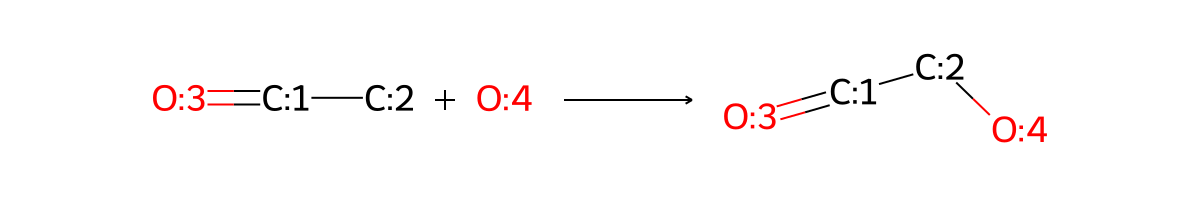

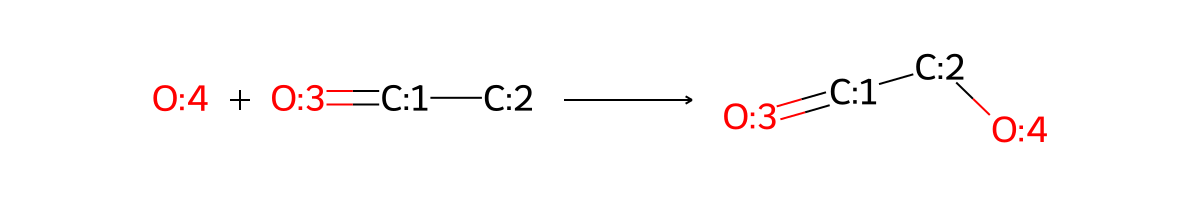

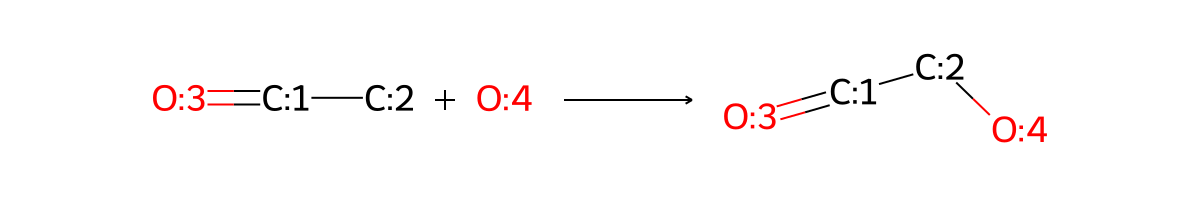

('[C].[O]', '[C][O]')
('[C].[O]', '[C][O]')
('[C].[O]', '[C][O]')


In [17]:
# Test permutation of reaction center function
amrxn1 = "[C:1](=[O:3])[C:2].[O:4]>>[C:1](=[O:3])[C:2][O:4]"
amrxn2 = "[O:4].[C:2][C:1](=[O:3])>>[C:1](=[O:3])[C:2][O:4]"
amrxn3 = "[C:2][C:1](=[O:3]).[O:4]>>[C:1](=[O:3])[C:2][O:4]"

display(SVG(draw_reaction(amrxn1)))
display(SVG(draw_reaction(amrxn2)))
display(SVG(draw_reaction(amrxn3)))

rc1 = get_rc_patts(amrxn1)
rc2 = get_rc_patts(amrxn2)
rc3 = get_rc_patts(amrxn3)
print(rc1)
print(rc2)
print(rc3)


Look via PathWrangler

In [ ]:
pw = PathWrangler(Path(study), Path(known))
tables = pw.get_paths()
paths = tables['paths']
krs = tables['known_reactions']
prs = tables['predicted_reactions']

pr2krs = dict(zip(prs['id'], prs['analogue_ids'].to_list()))
krs2enzymes = dict(zip(krs['id'], krs['enzymes'].to_list()))
prs2enzymes = defaultdict(list)
for p, ks in pr2krs.items():
    for k in ks:
        prs2enzymes[p] += krs2enzymes[k]

prs2smarts = dict(zip(prs['id'], prs['smarts'].to_list()))

paths = paths.select(
    pl.col("id"),
    pl.col("rxn_id"),
    (pl.col("generation") + 1).alias("step"),
    pl.col("starters").map_elements(lambda x : ";".join(x), return_dtype=pl.String),
    pl.col("targets").map_elements(lambda x : ";".join(x), return_dtype=pl.String),
    pl.col("rxn_id").replace_strict(prs2enzymes, default=[]).map_elements(lambda x : ";".join(x), return_dtype=pl.String).alias("enzymes"),
    pl.col("rxn_id").replace_strict(prs2smarts, default=None).alias("smarts")
)
paths

Formatting a pull for collaborators

In [ ]:
enzymes = tables['enzymes']


enzymes.with_columns(
    pl.col("id").map_elements(lambda x : f"https://www.uniprot.org/uniprotkb/{x}/entry", return_dtype=pl.String).alias("link"),
)

In [ ]:
paths.write_csv(
    Path(out_dir) / "250912_3hpa_paths.csv",
    separator=','
)

enzymes.write_csv(
    Path(out_dir) / "250912_3hpa_enzymes.csv",
    separator=','
)